# Exploratory Notebook

This notebook will be just to play with the data to get a logical pipeline before building out python files, and integrating with streamlit for reporting


## Config

In [ ]:

import os
import pandas as pd
import opensim as osim
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter,filtfilt


data_path= "data"
assets_path= "assets"
outputs_path= "outputs"
c3dFileAdapter= osim.C3DFileAdapter()
trcFileAdapter= osim.TRCFileAdapter()
stoFileAdapter = osim.STOFileAdapter()
osimModel = osim.Model(os.path.join(assets_path, "testing.osim"))
scaleTool = osim.ScaleTool(os.path.join(assets_path,"test_scale.xml"))





## Functions

In [ ]:
def rotate_markers_z_to_y(markersTable): #Convert to opensim coordinate system
    for i in range(markersTable.getNumRows()):
        row = markersTable.getRowAtIndex(i)
        for j in range(row.size()):
            vec = row[j]
            x, y, z = vec[0], vec[1], vec[2]
            row[j] = osim.Vec3(x, z, -y)
        markersTable.setRowAtIndex(i, row)
    return markersTable

def rotate_forces_z_to_y(forcesTable): # Also need to convert the forces coordiante system
    for i in range(forcesTable.getNumRows()):
        row = forcesTable.getRowAtIndex(i)
        for j in range(row.size()):
            vec = row[j]
            row[j] = osim.Vec3(vec[0], vec[2], -vec[1])
        forcesTable.setRowAtIndex(i, row)
    return forcesTable

def zero_unloaded_plates(forcesTable, threshold=10.0): #when the vertical force is below 10 Nm, zero the plate
    n_plates = forcesTable.getNumColumns() // 3
    for i in range(forcesTable.getNumRows()):
        row = forcesTable.getRowAtIndex(i)
        changed = False
        for p in range(n_plates):
            fc = p * 3  # force column index for this plate
            if abs(row[fc][1]) < threshold:  # component 1 = Y = vertical after rotation
                row[fc]     = osim.Vec3(0, 0, 0)
                row[fc + 1] = osim.Vec3(0, 0, 0)
                row[fc + 2] = osim.Vec3(0, 0, 0)
                changed = True
        if changed:
            forcesTable.setRowAtIndex(i, row)
    return forcesTable

def lowpass_filter_vec3_table(table, cutoff_hz): #generic filter for vec3 structure used by opensim
    times = list(table.getIndependentColumn())
    fs = 1.0 / (times[1] - times[0])
    b, a = butter(4, cutoff_hz / (fs / 2.0), btype='low')

    n_rows = table.getNumRows()
    n_cols = table.getNumColumns()

    data = np.zeros((n_rows, n_cols * 3))
    for i in range(n_rows):
        row = table.getRowAtIndex(i)
        for j in range(n_cols):
            vec = row[j]
            data[i, j * 3:j * 3 + 3] = [vec[0], vec[1], vec[2]]

    # filtfilt requires signal length > default padlen (3 * max(len(a), len(b))).
    # Cap padlen to half the signal length so short trials don't raise an error.
    padlen = min(3 * max(len(a), len(b)), (n_rows - 1) // 2)
    for c in range(data.shape[1]):
        data[:, c] = filtfilt(b, a, data[:, c], padlen=padlen)

    for i in range(n_rows):
        row = table.getRowAtIndex(i)
        for j in range(n_cols):
            row[j] = osim.Vec3(float(data[i, j * 3]), float(data[i, j * 3 + 1]), float(data[i, j * 3 + 2]))
        table.setRowAtIndex(i, row)

    return table

def filter_forces(forcesTable, cutoff_hz=30.0): #filter force data at specified cutoff with generic vec3 filter
    return lowpass_filter_vec3_table(forcesTable, cutoff_hz)


def filter_markers(markersTable, cutoff_hz=10.0): #filter marker data at a specified cutoff with generic vec3 filter
    return lowpass_filter_vec3_table(markersTable, cutoff_hz)

## Data Loading

### Static

In [ ]:

for file in os.listdir(data_path):
    if file.endswith(".c3d") and file.startswith("static"):
        static_c3d_file = os.path.join(data_path, file)

static_tables = c3dFileAdapter.read(static_c3d_file)
static_markersTable = c3dFileAdapter.getMarkersTable(static_tables)
static_markersTable = rotate_markers_z_to_y(static_markersTable)
static_markersTable = filter_markers(static_markersTable)



trcFileAdapter.write(static_markersTable, os.path.join(outputs_path, "static_markers.trc"))

static_forcesTable = c3dFileAdapter.getForcesTable(static_tables) #! Used to calculate mass


rows = []
for i in range(static_forcesTable.getNumRows()):
    row = static_forcesTable.getRowAtIndex(i)
    flat = []
    for j in range(row.size()):
        vec = row[j]
        flat.extend([vec[0], vec[1], vec[2]])
    rows.append(flat)

forces_matrix = np.array(rows)
fz1=forces_matrix[:, 2]
fz2=forces_matrix[:, 11]
fz3=forces_matrix[:, 20]
fz_total = fz1 + fz2 + fz3

mass= np.mean(fz_total) / 9.81 #! Will be used later





102.82605780742004


### Dynamic

In [ ]:
for file in os.listdir(data_path):
    if file.endswith(".c3d") and file.startswith("movement"):
        dynamic_c3d_file = os.path.join(data_path, file)


c3dFileAdapter.setLocationForForceExpression(osim.C3DFileAdapter.ForceLocation_CenterOfPressure)

dynamic_tables = c3dFileAdapter.read(dynamic_c3d_file)

print(dynamic_tables)

dynamic_markersTable = c3dFileAdapter.getMarkersTable(dynamic_tables)
dynamic_markersTable = rotate_markers_z_to_y(dynamic_markersTable)
trcFileAdapter.write(dynamic_markersTable, os.path.join(outputs_path, "dynamic_markers.trc"))


dynamic_forcesTable = c3dFileAdapter.getForcesTable(dynamic_tables) #! Will be used for inverse dynamics
dynamic_forcesTable = rotate_forces_z_to_y(dynamic_forcesTable)
dynamic_forcesTable = zero_unloaded_plates(dynamic_forcesTable, threshold=20.0)
dynamic_forcesTable = filter_forces(dynamic_forcesTable, cutoff_hz=10.0)



<opensim.common.StdMapStringAbstractDataTable; proxy of <Swig Object of type 'std::map< std::string,std::shared_ptr< OpenSim::AbstractDataTable > > *' at 0x0000029ED69C8210> >


### Time range for static


In [27]:
# Time range from static markers table
t_start = static_markersTable.getIndependentColumn()[0]
t_end = static_markersTable.getIndependentColumn()[-1]
timeRange = osim.ArrayDouble()
timeRange.set(0, t_start)
timeRange.set(1, t_end)

### Pathing

In [28]:
static_trc_path = os.path.join(outputs_path, "static_markers.trc")
scaled_model_path = os.path.join(outputs_path, "scaled_model.osim")
scaled_model_placed_path = os.path.join(outputs_path, "scaled_model_placed.osim")

### Scaling

In [29]:
scaleTool.setSubjectMass(abs(mass)) 
scaleTool.getGenericModelMaker().setModelFileName(os.path.join(assets_path, "testing.osim")) # Model scaler 
modelScaler = scaleTool.getModelScaler() 
modelScaler.setApply(True) 
modelScaler.setMarkerFileName(static_trc_path)
modelScaler.setTimeRange(timeRange) 
modelScaler.setPreserveMassDist(True) 
modelScaler.setOutputModelFileName(scaled_model_path) 
modelScaler.processModel(osimModel, "", abs(mass))

True

### Marker placing

In [30]:
scaled_model = osim.Model(scaled_model_path)
markerPlacer = scaleTool.getMarkerPlacer()
markerPlacer.setApply(True)
markerPlacer.setStaticPoseFileName(static_trc_path)
markerPlacer.setTimeRange(timeRange)
markerPlacer.setOutputModelFileName(scaled_model_placed_path)
markerPlacer.setMaxMarkerMovement(-1)
markerPlacer.processModel(scaled_model)

scaled_model.printToXML(scaled_model_path)

True

### Inverse Kinematics

In [31]:
scaled_placed_model= osim.Model(os.path.join(outputs_path, "scaled_model_placed.osim"))

ikTool = osim.InverseKinematicsTool()
ikTool.setModel(scaled_placed_model)
ikTool.setMarkerDataFileName(os.path.join(outputs_path, "dynamic_markers.trc"))
ikTool.setOutputMotionFileName(os.path.join(outputs_path, "ik_motion.mot"))
ikTool.run()



True

### Inverse Dynamics

In [36]:

# Write forces to .sto
stoFileAdapter.write(dynamic_forcesTable.flatten(), os.path.join(outputs_path, 'forces.sto'))

forces_sto_path    = os.path.abspath(os.path.join(outputs_path, "forces.sto"))
ik_mot_path        = os.path.abspath(os.path.join(outputs_path, "ik_motion.mot"))
ext_loads_xml_path = os.path.abspath(os.path.join(assets_path, "externalLoads.xml"))

id_model = osim.Model(scaled_model_placed_path)
id_tool  = osim.InverseDynamicsTool(os.path.abspath(os.path.join(assets_path, "IDSettings.xml")))
id_tool.setModel(id_model)
# coordinates_file in IDSettings.xml is relative to the xml, so override with absolute path
id_tool.setCoordinatesFileName(ik_mot_path)

# External loads — patch datafile path and write temp xml
ext_loads = osim.ExternalLoads(ext_loads_xml_path, True)
ext_loads.setDataFileName(forces_sto_path)

temp_ext_loads_xml = os.path.abspath("temp_ext_loads.xml")
ext_loads.printToXML(temp_ext_loads_xml)
id_tool.setExternalLoadsFileName(temp_ext_loads_xml)

id_tool.run()

os.remove(temp_ext_loads_xml)
print("Inverse dynamics complete → outputs/inverse_dynamics.sto")


Inverse dynamics complete → outputs/inverse_dynamics.sto


## Visualisation and analysis

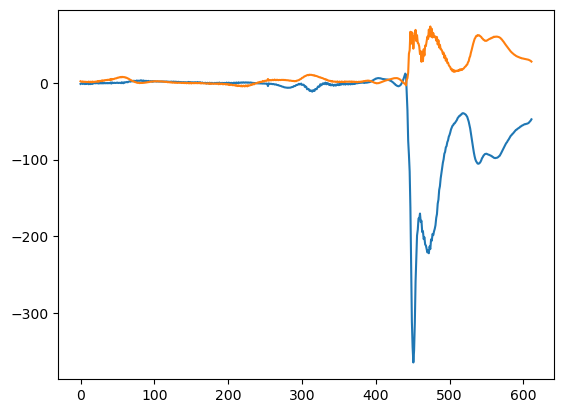

In [37]:

def load_mot(file_path): #* Dataframe for inverse kinematics joint angles
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Find end of header
    for i, line in enumerate(lines):
        if "endheader" in line.lower():
            start_idx = i + 1
            break

    # Load directly with pandas
    df = pd.read_csv(
        file_path,
        sep='\t',
        skiprows=start_idx,
        header=0   # first row after header is column names
    )

    return df

df = load_mot(os.path.join(outputs_path,"inverse_dynamics.sto"))

plt.plot(df['subtalar_angle_l_moment'], label='Right Knee Angle')
plt.plot(df['ankle_angle_l_moment'])
#plt.plot(df['ankle_angle_r_moment'])
# plt.plot(df['mtp_angle_l_moment']) #* Can change outcome for quick analysis in notebook
# plt.xlabel('Time')
# plt.ylabel('Knee Angle (degrees)')
# plt.title('Inverse Kinematics Results')
# plt.legend()
# plt.show()


## Model



In [48]:
#! nothing yet